# Spritdilemma 

Wir schauen uns an, wie sich die Gewinne eines deutschen Spediteurs verändern, wenn Deutschland und Polen Schutzmassnahmen ergreifen. Wir arbeiten mit einem einzigen Preis, der sich aber in den Szenarien verändert.

Der Gewinn ist

$$
G = P - K
$$

Nun müssen wir grob schauen wie sich Preise und Kosten in den Szenarien verändern.

## Preis

Wir gehen davon aus, dass der Preis bei offenen Märkten in beiden Ländern gleich ist. 

$$
P(DE = O, PL = O) = P_{eff}
$$

Wir wissen auch typischerweise im offenen Wettbewerb, dass der Preis nur geringfügig über den "günstigsten" Kosten liegt. In unserem Fall ist das oft der polnische Spediteur und wir schreiben sie als $K_{0,PL}$. Somit haben wir:

$$
P_{eff} = K_{0,PL} + \epsilon
$$
wobei $\epsilon$ eine kleine positive Zahl ist, die den Wettbewerb widerspiegelt
Weiterhin erwarten wir, das der Preis ansteigt, wenn in einem Land Schutzmassnahmen ergriffen werden.

- Wenn in Deutschland Schutzmassnahmen, dann steigt der Preis um $a_{DE}$.
- Wenn in Polen Schutzmassnahmen, dann steigt der Preis um $a_{PL}$.
- Wenn in beiden Ländern Schutzmassnahmen ein wenig auch um den Anstieg im anderen Land

Wir haben als Preis:

$$
P(DE = O, PL = O) = P_{eff}\\
P(DE = S, PL = O) = P_{eff} + a_{DE}\\
P(DE = O, PL = S) = P_{eff} + a_{PL}\\
P(DE = S, PL = S) = P_{eff} + a_{DE} + s_{P} \cdot a_{PL}
$$


## Kosten

Im gleichen Sinne können wir auch die Kosten modellieren. Hier sind aber im offenen Fall realistischerweise die Kosten in Polen niedriger als in Deutschland. Weiterhin verändern sich die Kosten bei Schutzmassnahmen in Deutschland für den deutschen Spediteur nicht wirklich (sie Zölle etc.)

$$
K_{D}(DE = O, PL = O) = K_{0,D}\\
K_{D}(DE = S, PL = O) = K_{0,D}\\
K_{D}(DE = O, PL = S) = K_{0,D} + k_{PL}\\
K_{D}(DE = S, PL = S) = K_{0,D} + k_{PL} + s_{K} \cdot k_{DE}
$$

Spiegelbildlich für Polen:

$$
K_{P}(DE = O, PL = O) = K_{0,P}\\
K_{P}(DE = S, PL = O) = K_{0,P} + k_{DE}\\
K_{P}(DE = O, PL = S) = K_{0,P}\\
K_{P}(DE = S, PL = S) = K_{0,P} + s_{K} \cdot k_{DE} + k_{PL}
$$

## Gewinn

Wir können nun die Gewinne in den vier Szenarien berechnen:

$$
G_{D}(DE = O, PL = O) = P_{eff} - K_{0,D}\\
G_{D}(DE = S, PL = O) = P_{eff} + a_{DE} - K_{0,D}\\
G_{D}(DE = O, PL = S) = P_{eff} + a_{PL} - (K_{0,D} + k_{PL})\\
G_{D}(DE = S, PL = S) = P_{eff} + a_{DE} + s_{P} \cdot a_{PL} - (K_{0,D} + k_{PL} + s_{K} \cdot k_{DE})
$$


## Erwartungswerte
Was passiert also für einen deutschen Spediteur, wenn Deutschland offen ist ? Wir nehmen an, dass Polen mit der Wahrscheinlichkeit $p_{PL}$ schliesst. Dann ist der Erwartungswert:

$$
E_{D}(DE = O) = G_{D}(DE = O, PL = S) \cdot p_{PL} + G_{D}(DE = O, PL = O) \cdot (1-p_{PL})\\
= \left[P_{eff} + a_{PL} - (K_{0,D} + k_{PL})\right] \cdot p_{PL} + (P_{eff} - K_{0,D}) \cdot (1-p_{PL})\\
= P_{eff} - K_{0,D}  +  \left[ a_{PL} -  k_{PL}\right] \cdot p_{PL}
$$

Jetzt der Erwartungswert, wenn Deutschland schliesst:

$$
E_{D}(DE = S) = G_{D}(DE = S, PL = S) \cdot p_{PL} + G_{D}(DE = S, PL = O) \cdot (1-p_{PL})\\
= \left[P_{eff} + a_{DE} + s_{P} \cdot a_{PL} - (K_{0,D} + k_{PL} + s_{K} \cdot k_{DE})\right] \cdot p_{PL} + (P_{eff} + a_{DE} - K_{0,D}) \cdot (1-p_{PL})\\
= (P_{eff} + a_{DE} - K_{0,D}) +\left[ s_{P} \cdot a_{PL} - k_{PL} - s_{K} \cdot k_{DE})\right] \cdot p_{PL} \\
$$

Let us now compare the two expectation values:

$$
E_{D}(DE = S) - E_{D}(DE = O) = a_{DE} -\left[ (1-s_{P}) \cdot a_{PL} + s_{K} \cdot k_{DE}\right] \cdot p_{PL}
$$

In [65]:
# O = Offen, S = Schutz
players = ["DE", "PL"]
actions = ["O", "S"]

# Sehr einfaches Gewinnmodell: Gewinn = Preis - Kosten

eff_cost_de = 6
eff_cost_pl = 6
eff_price = eff_cost_pl + 0.5 # German logistics company is not profitable

# anstieg bei schutz
anstieg_schutz_de = 1
anstieg_schutz_pl = 1
spillover = 0.3


zoll_de = 2
zoll_pl = 2
spillover_cost = 0.5


price = {
    ("O", "O"): eff_price,
    ("O", "S"): eff_price+anstieg_schutz_pl,
    ("S", "O"): eff_price + anstieg_schutz_de,
    ("S", "S"): eff_price + anstieg_schutz_de + spillover * anstieg_schutz_pl,
}


cost_de = {
    ("O", "O"): eff_cost_de,
    ("O", "S"): eff_cost_de + zoll_pl,
    ("S", "O"): eff_cost_de,
    ("S", "S"): eff_cost_de + zoll_pl + spillover_cost * zoll_de,
}
cost_pl = {
    ("O", "O"): eff_cost_pl,
    ("O", "S"): eff_cost_pl,
    ("S", "O"): eff_cost_pl + zoll_de,
    ("S", "S"): eff_cost_pl + zoll_de + spillover_cost * zoll_pl,
}

# payoff[(aktion_DE, aktion_PL)] = (gewinn_DE, gewinn_PL)
payoff = {
    s: (price[s] - cost_de[s], price[s] - cost_pl[s])
    for s in [(a, b) for a in actions for b in actions]
}

print("Payoff-Matrix (aus Gewinn = Preis - Kosten):", payoff)
def br_de(action_pl):
    return max(actions, key=lambda a: payoff[(a, action_pl)][0])

def br_pl(action_de):
    return max(actions, key=lambda b: payoff[(action_de, b)][1])


Payoff-Matrix (aus Gewinn = Preis - Kosten): {('O', 'O'): (0.5, 0.5), ('O', 'S'): (-0.5, 1.5), ('S', 'O'): (1.5, -0.5), ('S', 'S'): (-1.2000000000000002, -1.2000000000000002)}


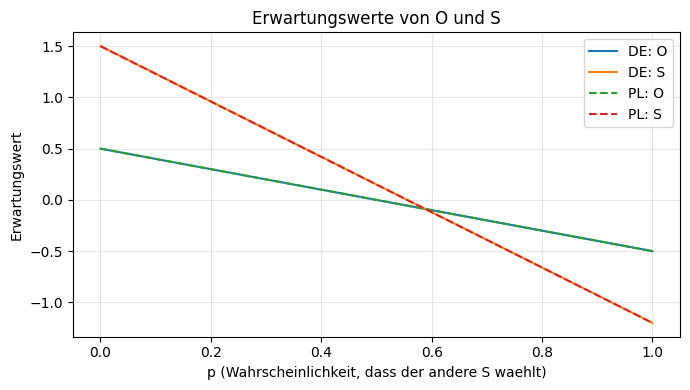

In [66]:
# Erwartungswerte bei p = Wahrscheinlichkeit, dass der andere S waehlt
import matplotlib.pyplot as plt


def ev_de(p):
    return {
        "O": (1 - p) * payoff[("O", "O")][0] + p * payoff[("O", "S")][0],
        "S": (1 - p) * payoff[("S", "O")][0] + p * payoff[("S", "S")][0],
    }


def ev_pl(p):
    return {
        "O": (1 - p) * payoff[("O", "O")][1] + p * payoff[("S", "O")][1],
        "S": (1 - p) * payoff[("O", "S")][1] + p * payoff[("S", "S")][1],
    }


ps = [i / 20 for i in range(21)]
de_o = [ev_de(p)["O"] for p in ps]
de_s = [ev_de(p)["S"] for p in ps]
pl_o = [ev_pl(p)["O"] for p in ps]
pl_s = [ev_pl(p)["S"] for p in ps]

plt.figure(figsize=(7, 4))
plt.plot(ps, de_o, label="DE: O")
plt.plot(ps, de_s, label="DE: S")
plt.plot(ps, pl_o, label="PL: O", linestyle="--")
plt.plot(ps, pl_s, label="PL: S", linestyle="--")
plt.xlabel("p (Wahrscheinlichkeit, dass der andere S waehlt)")
plt.ylabel("Erwartungswert")
plt.title("Erwartungswerte von O und S")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
# Nash-Gleichgewicht und Gesamtgewinne
eq = [(a,b) for a in actions for b in actions if a == br_de(b) and b == br_pl(a)]
total_profit = {s: payoff[s][0] + payoff[s][1] for s in payoff}
print('Nash-Gleichgewicht:', eq)
print('Gesamtgewinne:', total_profit)
print('G_D(O,O):', payoff[('O','O')][0], '| G_PL(O,O):', payoff[('O','O')][1])

Nash-Gleichgewicht: [('O', 'S'), ('S', 'O')]
Gesamtgewinne: {('O', 'O'): 1.0, ('O', 'S'): 1.0, ('S', 'O'): 1.0, ('S', 'S'): -2.4000000000000004}
G_D(O,O): 0.5 | G_PL(O,O): 0.5


# Mit Nachfrage Modellierung

Im Modell oben haben wir überhaupt nicht berücksichtigt, dass die Nachfrage in den Szenarien unterschiedlich sein könnte. Hierfür machen wir den Gewinn ein wenig komplexer und zwar:

$$
G = (P-K) \cdot M
$$

Der Gewinn ist im grossen und ganzen die Marge (P-K) multipliziert mit der verkauften Menge M. Für die Menge nehmen wir nun an, dass sie vom Preis abhäng.

$$
M(P) = M_0 \left(1 - \alpha \cdot \frac{P - P_{eff}}{P_{eff}}\right)
$$

In [68]:
def verkaufte_menge(preis, m0, peff, alpha):
    return m0 * (1- alpha*(preis-peff) / peff)

In [69]:
# O = Offen, S = Schutz
players = ["DE", "PL"]
actions = ["O", "S"]

# Sehr einfaches Gewinnmodell mit Nachfrage: Gewinn = (Preis - Kosten) * Menge
eff_cost_de = 7
eff_cost_pl = 6
eff_price = eff_cost_pl + 0.5  # German logistics company is not profitable

# anstieg bei schutz
anstieg_schutz_de = 1
anstieg_schutz_pl = 0.6
spillover = 0.3

zoll_de = 0.5
zoll_pl = 0.5
spillover_cost = 0.2

price = {
    ("O", "O"): eff_price,
    ("O", "S"): eff_price + anstieg_schutz_pl,
    ("S", "O"): eff_price + anstieg_schutz_de,
    ("S", "S"): eff_price + anstieg_schutz_de + spillover * anstieg_schutz_pl,
}

cost_de = {
    ("O", "O"): eff_cost_de,
    ("O", "S"): eff_cost_de + zoll_pl,
    ("S", "O"): eff_cost_de,
    ("S", "S"): eff_cost_de + zoll_pl + spillover_cost * zoll_de,
}
cost_pl = {
    ("O", "O"): eff_cost_pl,
    ("O", "S"): eff_cost_pl,
    ("S", "O"): eff_cost_pl + zoll_de,
    ("S", "S"): eff_cost_pl + zoll_de + spillover_cost * zoll_pl,
}

# Nachfrage-Parameter
m0_de, m0_pl = 1, 1
# alpha_de, alpha_pl = 3, 3
alpha_de, alpha_pl = 1.5, 1.5
qty_de = {
    s: verkaufte_menge(price[s], m0_de, eff_price, alpha_de)
    for s in [(a, b) for a in actions for b in actions]
}
qty_pl = {s: verkaufte_menge(price[s], m0_pl, eff_price, alpha_pl) for s in [(a, b) for a in actions for b in actions]}

print(qty_de)
print(qty_pl)
# payoff[(aktion_DE, aktion_PL)] = (gewinn_DE, gewinn_PL)
payoff = {
    s: (
        (price[s] - cost_de[s]) * qty_de[s],
        (price[s] - cost_pl[s]) * qty_pl[s],
    )
    for s in [(a, b) for a in actions for b in actions]
}

print("Payoff-Matrix (mit Menge):", payoff)

{('O', 'O'): 1.0, ('O', 'S'): 0.8615384615384616, ('S', 'O'): 0.7692307692307692, ('S', 'S'): 0.7276923076923077}
{('O', 'O'): 1.0, ('O', 'S'): 0.8615384615384616, ('S', 'O'): 0.7692307692307692, ('S', 'S'): 0.7276923076923077}
Payoff-Matrix (mit Menge): {('O', 'O'): (-0.5, 0.5), ('O', 'S'): (-0.34461538461538493, 0.9476923076923074), ('S', 'O'): (0.3846153846153846, 0.7692307692307692), ('S', 'S'): (0.05821538461538467, 0.7859076923076924)}


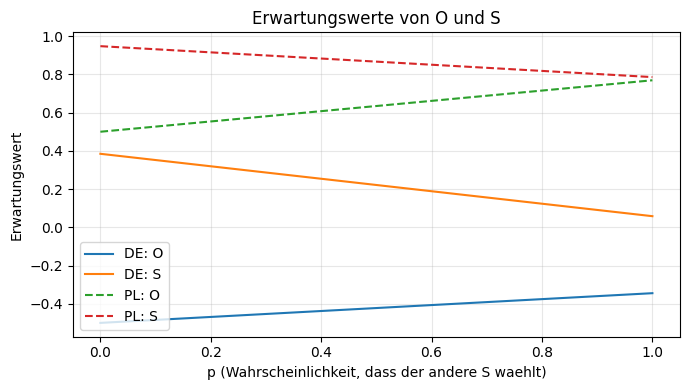

In [70]:
# Erwartungswerte bei p = Wahrscheinlichkeit, dass der andere S waehlt
import matplotlib.pyplot as plt


def ev_de(p):
    return {
        "O": (1 - p) * payoff[("O", "O")][0] + p * payoff[("O", "S")][0],
        "S": (1 - p) * payoff[("S", "O")][0] + p * payoff[("S", "S")][0],
    }


def ev_pl(p):
    return {
        "O": (1 - p) * payoff[("O", "O")][1] + p * payoff[("S", "O")][1],
        "S": (1 - p) * payoff[("O", "S")][1] + p * payoff[("S", "S")][1],
    }


ps = [i / 20 for i in range(21)]
de_o = [ev_de(p)["O"] for p in ps]
de_s = [ev_de(p)["S"] for p in ps]
pl_o = [ev_pl(p)["O"] for p in ps]
pl_s = [ev_pl(p)["S"] for p in ps]

plt.figure(figsize=(7, 4))
plt.plot(ps, de_o, label="DE: O")
plt.plot(ps, de_s, label="DE: S")
plt.plot(ps, pl_o, label="PL: O", linestyle="--")
plt.plot(ps, pl_s, label="PL: S", linestyle="--")
plt.xlabel("p (Wahrscheinlichkeit, dass der andere S waehlt)")
plt.ylabel("Erwartungswert")
plt.title("Erwartungswerte von O und S")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Policy-Analyse

Welche politischen Maßnahmen können Kooperation (O,O) für den deutschen Spediteur rational machen?

Wir vergleichen vier Szenarien:
- **Status quo**: aktuelle Parameter
- **Subvention DE**: K_0,D sinkt durch Steuerentlastung / Dieselsubvention
- **EU-Standards**: K_0,P steigt durch EU-Mindestlohnharmonisierung
- **Beide**: Subvention + EU-Standards kombiniert

Bedingung für rationale Kooperation (DE bevorzugt O):
$$E_D(DE=S) - E_D(DE=O) = a_{DE} - \left[(1-s_P) \cdot a_{PL} + s_K \cdot k_{DE}\right] \cdot p_{PL} < 0$$

In [71]:
import pandas as pd

# Kooperationsbedingung fuer Deutschland (bei p_PL=1, sichere Vergeltung):
# E_D(S) - E_D(O) = a_DE - [(1-s_P)*a_PL + s_K*k_DE] * p_PL < 0
# => a_DE < (1-s_P)*a_PL + s_K*k_DE
#
# Hebel:
#   - G_D(O,O) > 0 erzwingen: K_0,D senken (Subvention) oder K_0,P erhoehen (EU-Standards)
#   - Vorteil von S verringern: a_DE senken ODER k_DE erhoehen (starke Vergeltung)

def berechne_szenario(label, cost_de_neu, cost_pl_neu, a_de_neu, k_de_neu):
    p_eff = cost_pl_neu + 0.5  # Marktpreis = polnische Kosten + Marge
    g_oo_de = p_eff - cost_de_neu
    g_oo_pl = p_eff - cost_pl_neu
    rhs = ((1 - spillover) * anstieg_schutz_pl + spillover_cost * k_de_neu) * 1.0
    vorteil_s = a_de_neu - rhs
    if g_oo_de > 0 and vorteil_s < 0:
        koop = 'JA'
    elif g_oo_de > 0:
        koop = 'profitabel, S dominiert'
    else:
        koop = 'nein (Verlust bei O,O)'
    return {
        'Szenario': label,
        'K_0,D': cost_de_neu,
        'K_0,P': cost_pl_neu,
        'a_DE': a_de_neu,
        'k_DE': k_de_neu,
        'G_D(O,O)': round(g_oo_de, 2),
        'Vorteil S': round(vorteil_s, 2),
        'Kooperation': koop,
    }

szenarien = [
    berechne_szenario('Status quo',               7.0, 6.0, anstieg_schutz_de, zoll_de),
    berechne_szenario('Subvention DE',            6.3, 6.0, anstieg_schutz_de, zoll_de),
    berechne_szenario('EU-Standards',             7.0, 6.5, anstieg_schutz_de, zoll_de),
    berechne_szenario('Subvention + EU-Standards',6.3, 6.5, anstieg_schutz_de, zoll_de),
    berechne_szenario('Starke Vergeltung (k_DE=2)',6.3, 6.0, anstieg_schutz_de, 2.0),
    berechne_szenario('Alles kombiniert',         6.3, 6.5, anstieg_schutz_de, 2.0),
    berechne_szenario('Subvention + Vergeltung k=3', 6.3, 6.0, anstieg_schutz_de, 3.0),
    berechne_szenario('*** Kooperation moeglich ***', 6.3, 6.5, anstieg_schutz_de, 3.0),
]

df = pd.DataFrame(szenarien)
print(df.to_string(index=False))

                    Szenario  K_0,D  K_0,P  a_DE  k_DE  G_D(O,O)  Vorteil S             Kooperation
                  Status quo    7.0    6.0     1   0.5      -0.5       0.48  nein (Verlust bei O,O)
               Subvention DE    6.3    6.0     1   0.5       0.2       0.48 profitabel, S dominiert
                EU-Standards    7.0    6.5     1   0.5       0.0       0.48  nein (Verlust bei O,O)
   Subvention + EU-Standards    6.3    6.5     1   0.5       0.7       0.48 profitabel, S dominiert
  Starke Vergeltung (k_DE=2)    6.3    6.0     1   2.0       0.2       0.18 profitabel, S dominiert
            Alles kombiniert    6.3    6.5     1   2.0       0.7       0.18 profitabel, S dominiert
 Subvention + Vergeltung k=3    6.3    6.0     1   3.0       0.2      -0.02                      JA
*** Kooperation moeglich ***    6.3    6.5     1   3.0       0.7      -0.02                      JA


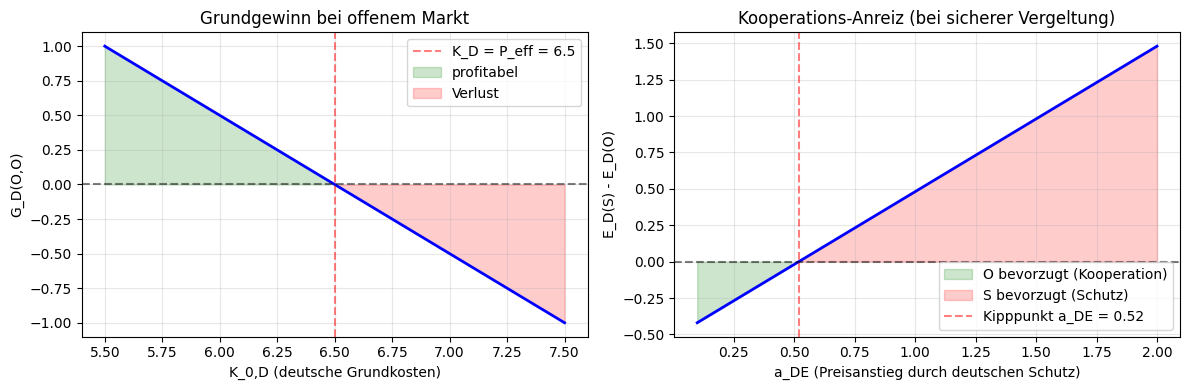

Kipppunkt: Kooperation rational wenn a_DE < 0.52
Aktueller Wert: a_DE = 1


In [72]:
import numpy as np
import matplotlib.pyplot as plt

# 2D-Heatmap: G_D(O,O) als Funktion von K_0,D und a_DE
# Zeigt wann Kooperation (O,O) sowohl profitabel als auch rational ist
cost_de_vals = np.linspace(5.5, 7.5, 50)
a_de_vals = np.linspace(0.1, 2.0, 50)

p_eff_fix = 6.5  # Marktpreis fix fuer diese Analyse
rhs = ((1 - spillover) * anstieg_schutz_pl + spillover_cost * zoll_de) * 1.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: G_D(O,O) als Funktion von K_0,D
ax = axes[0]
g_oo = p_eff_fix - cost_de_vals
ax.plot(cost_de_vals, g_oo, 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.axvline(p_eff_fix, color='r', linestyle='--', alpha=0.5, label=f'K_D = P_eff = {p_eff_fix}')
ax.fill_between(cost_de_vals, g_oo, 0, where=g_oo > 0, alpha=0.2, color='green', label='profitabel')
ax.fill_between(cost_de_vals, g_oo, 0, where=g_oo <= 0, alpha=0.2, color='red', label='Verlust')
ax.set_xlabel('K_0,D (deutsche Grundkosten)')
ax.set_ylabel('G_D(O,O)')
ax.set_title('Grundgewinn bei offenem Markt')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Vorteil S vs. O als Funktion von a_DE (bei p_PL=1)
ax = axes[1]
vorteil = a_de_vals - rhs
ax.plot(a_de_vals, vorteil, 'b-', linewidth=2)
ax.axhline(0, color='k', linestyle='--', alpha=0.5)
ax.fill_between(a_de_vals, vorteil, 0, where=vorteil < 0, alpha=0.2, color='green', label='O bevorzugt (Kooperation)')
ax.fill_between(a_de_vals, vorteil, 0, where=vorteil >= 0, alpha=0.2, color='red', label='S bevorzugt (Schutz)')
ax.axvline(rhs, color='r', linestyle='--', alpha=0.5, label=f'Kipppunkt a_DE = {rhs:.2f}')
ax.set_xlabel('a_DE (Preisanstieg durch deutschen Schutz)')
ax.set_ylabel('E_D(S) - E_D(O)')
ax.set_title('Kooperations-Anreiz (bei sicherer Vergeltung)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f'Kipppunkt: Kooperation rational wenn a_DE < {rhs:.2f}')
print(f'Aktueller Wert: a_DE = {anstieg_schutz_de}')